# HW3 – CIFAR-10 圖庫資料庫（MLP）

## 作業說明
- 使用 `cifar10.load_data()` 載入 CIFAR-10
- 調整 **MLP 層數** 與 **每層神經元個數**
- 找出 **測試資料庫最佳**（以 test accuracy 為主）

---


在終端機執行：

conda create -n mlhw3 python=3.10 -y

conda activate mlhw3

pip install --upgrade pip

pip install "tensorflow==2.15.*" notebook ipykernel


然後開 Notebook：

jupyter notebook



In [21]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow:", tf.__version__)

# Resubmitable：固定亂數種子
SEED = 1
tf.random.set_seed(SEED)
np.random.seed(SEED)


TensorFlow: 2.15.1


## 1) 載入 CIFAR-10：`cifar10.load_data()`
CIFAR-10：32×32×3 的彩色圖片，共 10 類。


X_train: (50000, 32, 32, 3) y_train: (50000, 1)
X_test : (10000, 32, 32, 3) y_test : (10000, 1)


/var/folders/86/y_99dj0x6zz7k3v0wthtkrc80000gn/T/ipykernel_60488/936367629.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])], fontsize=9)


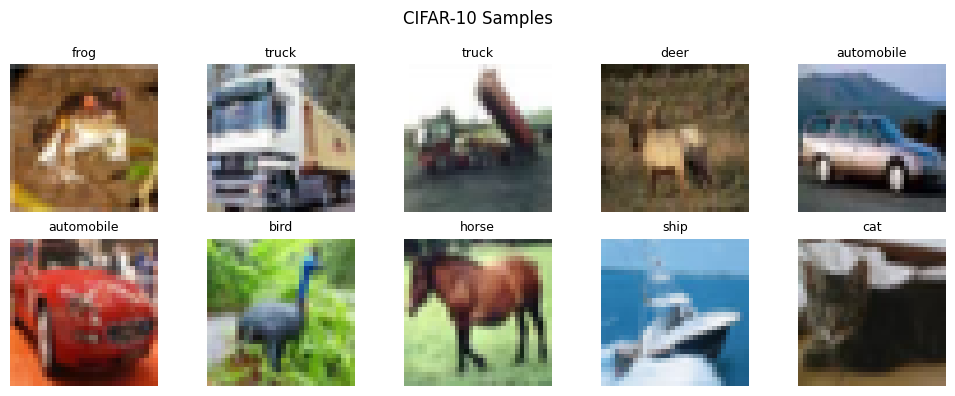

In [22]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i])], fontsize=9)
    plt.axis('off')
plt.suptitle("CIFAR-10 Samples")
plt.tight_layout()
plt.show()


## 2) 前處理
MLP 需要向量輸入：把 32×32×3 展平成 3072 維。


In [23]:
# Normalize to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# One-hot
y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test, 10)

# Flatten for MLP
X_train_flat = X_train.reshape(len(X_train), -1)  # (50000, 3072)
X_test_flat  = X_test.reshape(len(X_test), -1)    # (10000, 3072)

print("X_train_flat:", X_train_flat.shape)
print("X_test_flat :", X_test_flat.shape)


X_train_flat: (50000, 3072)
X_test_flat : (10000, 3072)


## 3) 建立可調參數的 MLP
- `hidden_units`：例如 `[1024, 512, 256]` = 3 層隱藏層
- `dropout` / `l2_lambda`：用來降低過擬合


In [24]:
def build_mlp(hidden_units, dropout=dropout, l2_lambda=l2_lambda, lr=1e-3):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for u in hidden_units:
        if l2_lambda > 0:
            model.add(layers.Dense(u, activation='relu',
                                   kernel_regularizer=regularizers.l2(l2_lambda)))
        else:
            model.add(layers.Dense(u, activation='relu'))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))

    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


## 4) 層數/神經元
> CIFAR-10 用純 MLP 表現通常不如 CNN。



In [25]:
configs = [
    [512],
    [1024, 512],
    [1024, 512, 256],
]

dropouts = [0.2]      
l2_lambdas = [0.0]    

EPOCHS = 8            
BATCH_SIZE = 256      
VALIDATION_SPLIT = 0.2



## 5) Test Accuracy 最佳的組合


In [18]:
for hidden_units in configs:
    for dropout in dropouts:
        for l2_lambda in l2_lambdas:
            print("=" * 90)
            print(f"Config: units={hidden_units}, dropout={dropout}, l2={l2_lambda}")
            
            model = build_mlp(hidden_units, dropout=dropout, l2_lambda=l2_lambda, lr=1e-3)

            history = model.fit(
                X_train_flat, y_train_oh,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                validation_split=VALIDATION_SPLIT,
                callbacks=callbacks,
                verbose=2
            )

            best_val_acc = float(max(history.history['val_accuracy']))
            test_loss, test_acc = model.evaluate(X_test_flat, y_test_oh, verbose=0)

            row = {
                "hidden_units": hidden_units,
                "dropout": float(dropout),
                "l2_lambda": float(l2_lambda),
                "best_val_acc": best_val_acc,
                "test_acc": float(test_acc),
            }
            results.append(row)

            print(f"Best Val Acc: {best_val_acc:.4f} | Test Acc: {test_acc:.4f}")

            if (best is None) or (test_acc > best["test_acc"]):
                best = row
                best_model = model

print("\n✅ DONE. Total tried:", len(results))


Config: units=[512], dropout=0.2, l2=0.0


NameError: name 'num_classes' is not defined

## 6) 最佳解（Test Accuracy 最高）


In [ ]:
results_sorted = sorted(results, key=lambda d: d["test_acc"], reverse=True)

print("Top configs by Test Accuracy:")
for i, r in enumerate(results_sorted[:10], 1):
    print(f"{i:2d}. units={r['hidden_units']}, dropout={r['dropout']}, l2={r['l2_lambda']} | "
          f"val_best={r['best_val_acc']:.4f}, test={r['test_acc']:.4f}")

print("\n🏆 BEST (by Test Accuracy):", best)


## 7) 最佳模型學習曲線（Accuracy / Loss）


In [ ]:
best_units = best["hidden_units"]
best_dropout = best["dropout"]
best_l2 = best["l2_lambda"]

best_model2 = build_mlp(input_dim, num_classes, best_units,
                        dropout=best_dropout, l2_lambda=best_l2, lr=1e-3)

history = best_model2.fit(
    X_train_flat, y_train_oh,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=2
)

test_loss, test_acc = best_model2.evaluate(X_test_flat, y_test_oh, verbose=0)
print(f"Re-train BEST config Test Acc: {test_acc:.4f}")

plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Best MLP – Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Best MLP – Loss')
plt.legend()
plt.show()
